In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
def extractRedLine2HeightVector(img_path, save_path=None):
    # 读取图像并转换为RGB
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 分离通道计算红色程度
    r = img_rgb[:, :, 0].astype(np.float32)
    g = img_rgb[:, :, 1].astype(np.float32)
    b = img_rgb[:, :, 2].astype(np.float32)
    redness = r - (g + b) / 2
    
    # 归一化到0-255并转为uint8
    redness_norm = cv2.normalize(redness, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    
    # 边缘检测（霍夫变换需要边缘图）
    edges = cv2.Canny(redness_norm, 50, 150)
    # ===== 形态学处理 =====
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))  # 椭圆形核
    # 膨胀：连接断裂的边缘
    dilated = cv2.dilate(edges, kernel, iterations=2)
    
    # 闭运算（先膨胀后腐蚀）：填充小孔，连接邻近边缘
    closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=2)

    # 获取图像尺寸
    h, w = redness.shape
    
    height_vector = []
    # 单列提取
    for col_index in range(w):
        column = closed[:, col_index]
        white_positions = np.where(column == 255)[0]
        
        if len(white_positions) > 0:
            midpoint = int(np.mean(white_positions))
            height_vector.append(midpoint)
            # print(f"第{col_index}列白色区间中点: {midpoint}")
        else:
            # print(f"第{col_index}列没有白色像素")
            height_vector.append(height_vector[len(height_vector)-1])
    height_vector = np.array(height_vector)
    if save_path != None:
        plt.figure()
        plt.plot(height_vector, 'r-', linewidth=1.5)
        plt.title('height vector')
        plt.xlabel('col')
        plt.ylabel('row')
        plt.grid(True, alpha=0.3)
        plt.savefig(save_path)  # 保存为PNG格式
        
    return height_vector

/tmp/ipykernel_17/2643577630.py:43: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()
libpng error: IDAT: CRC error


error.


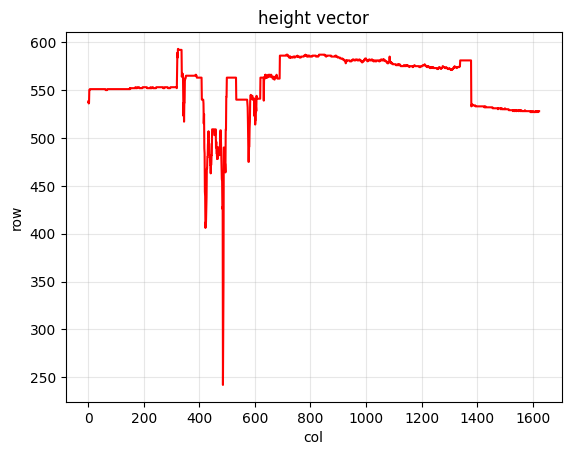

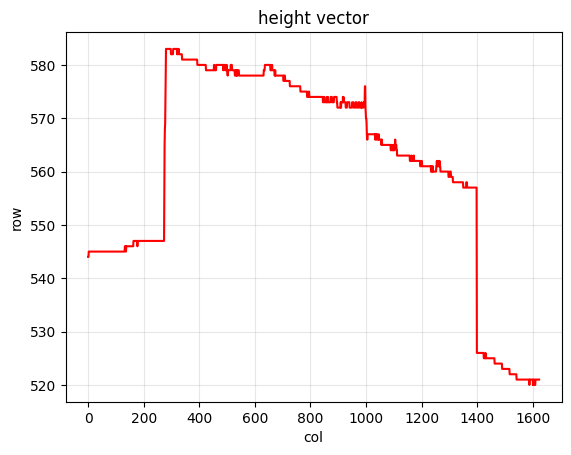

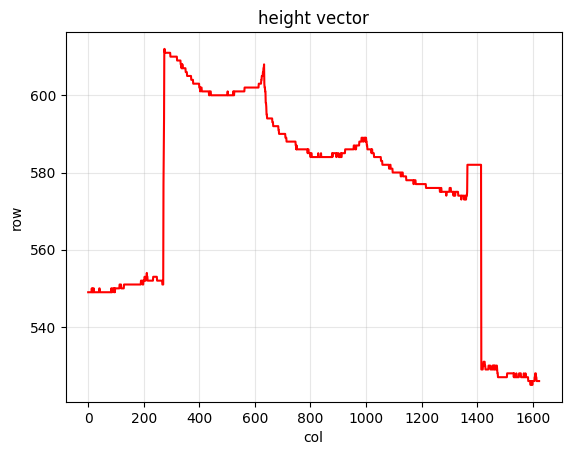

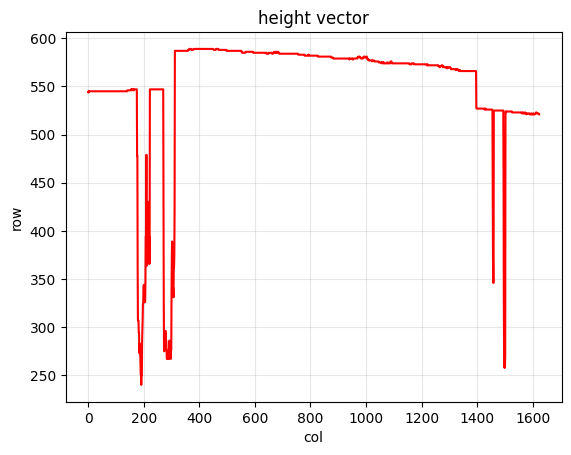

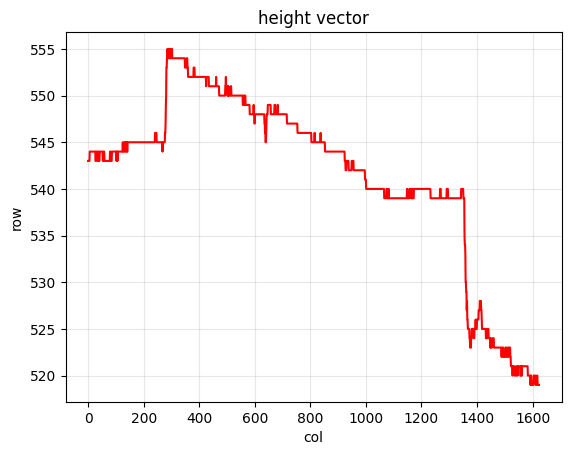

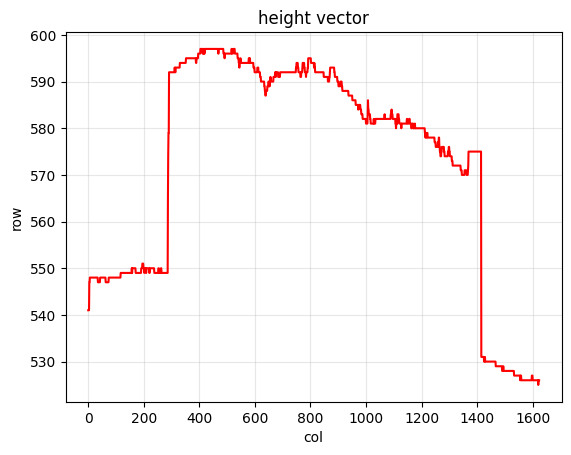

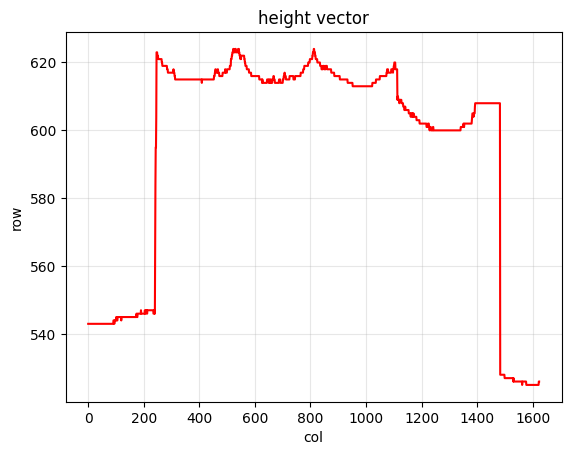

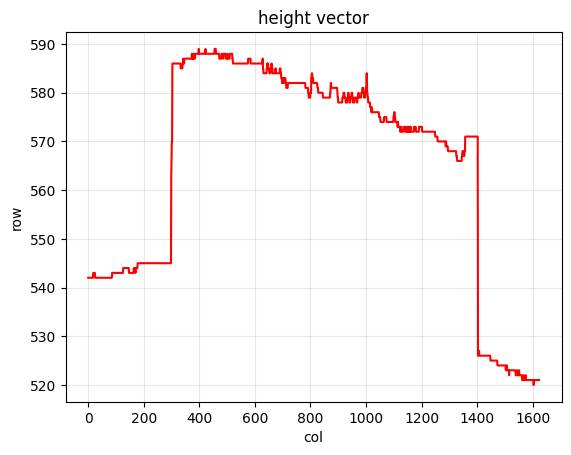

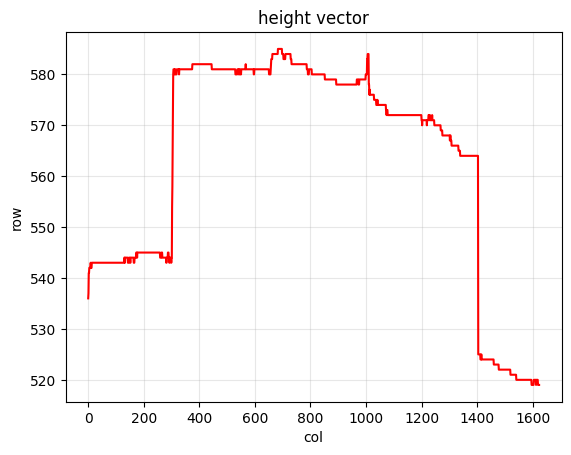

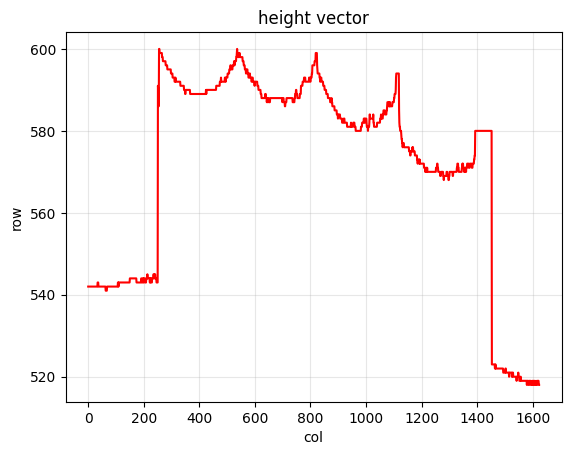

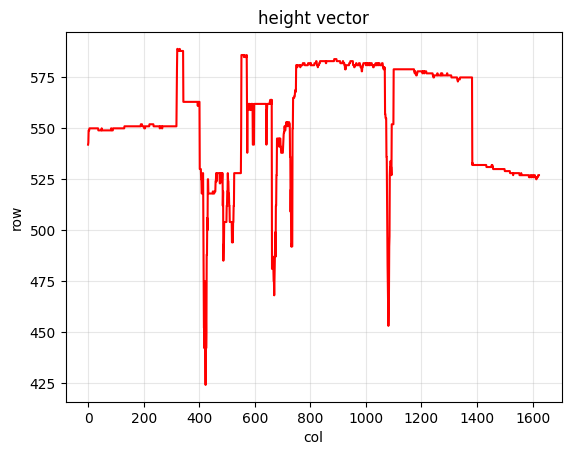

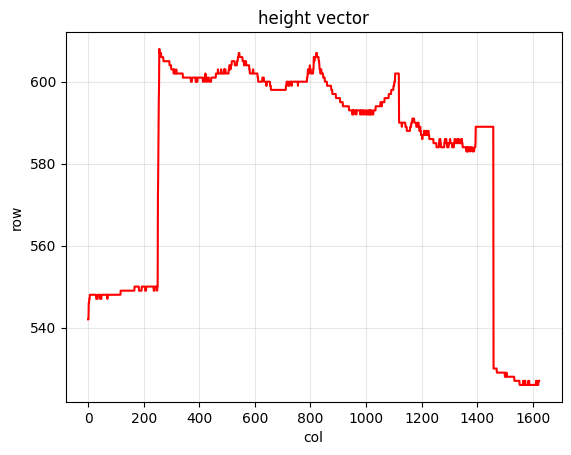

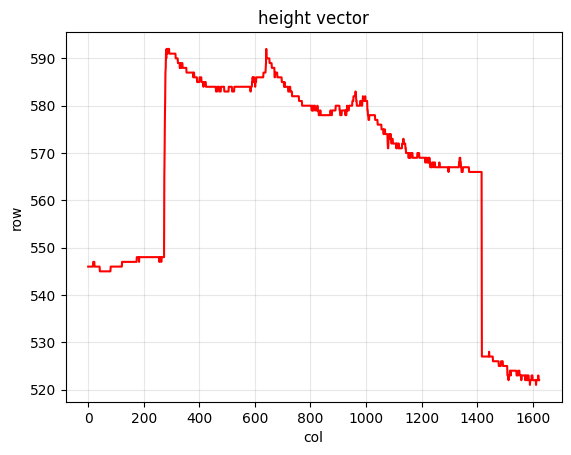

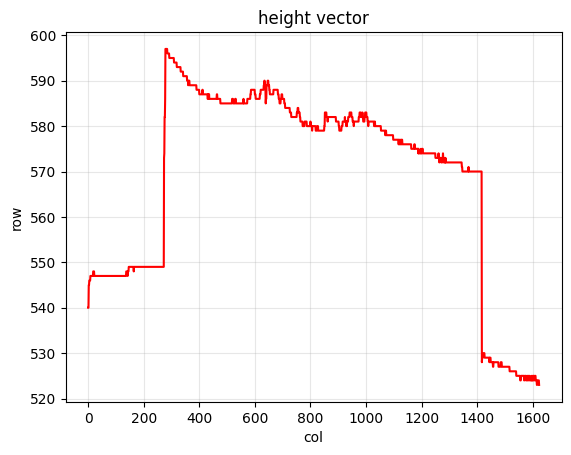

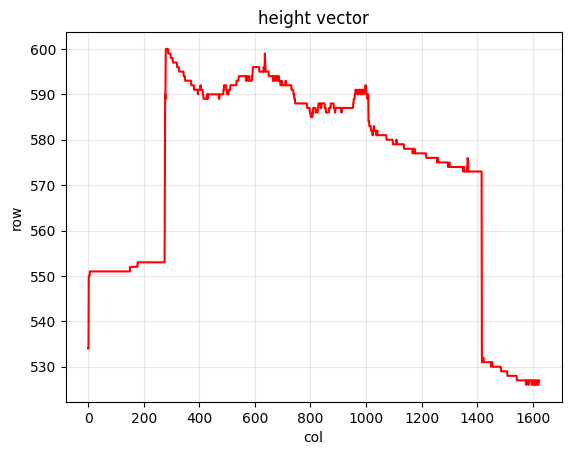

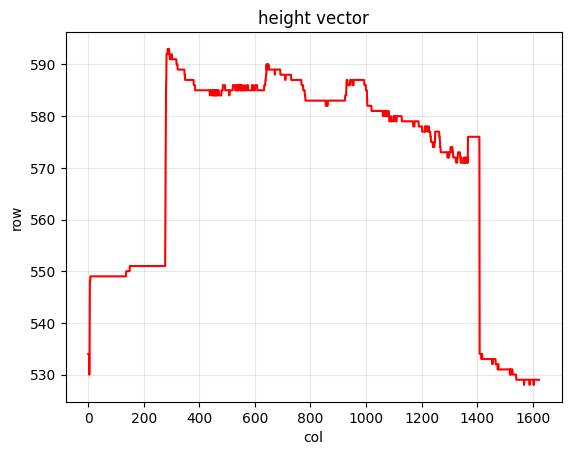

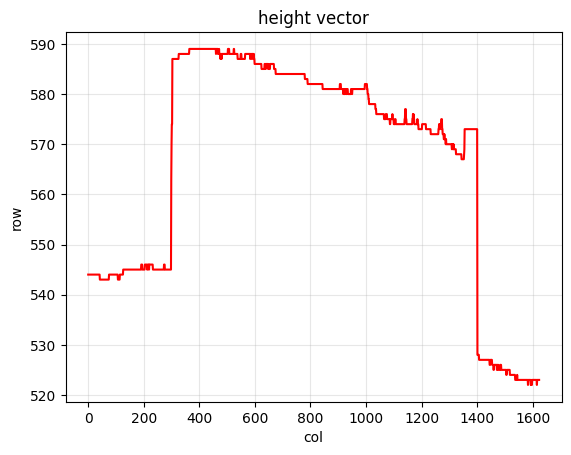

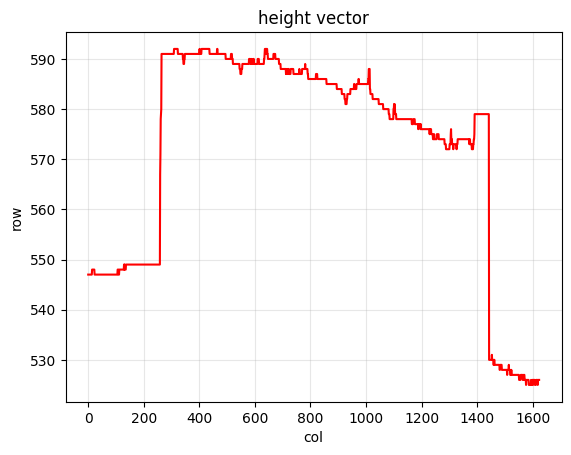

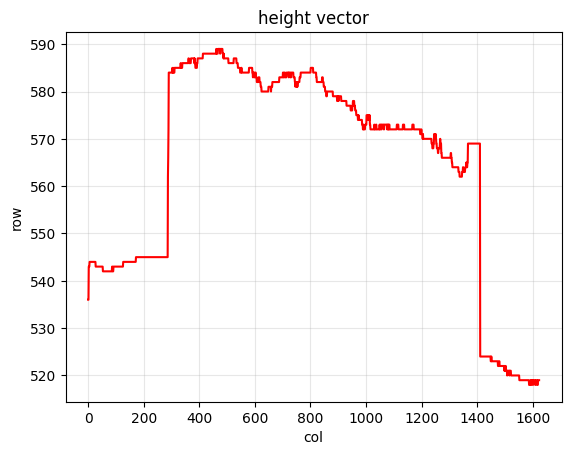

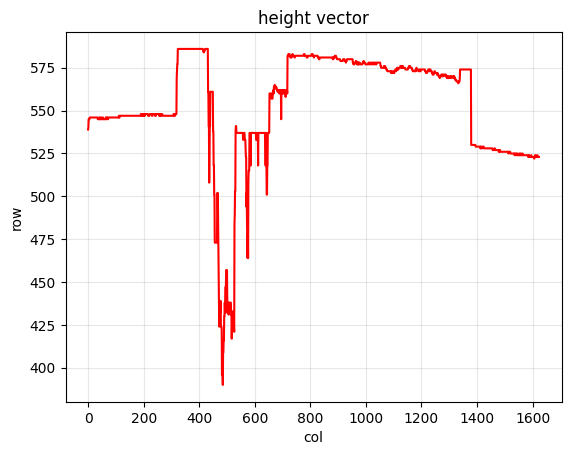

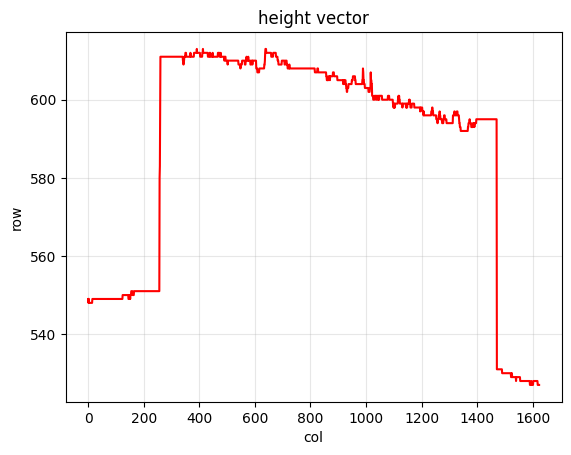

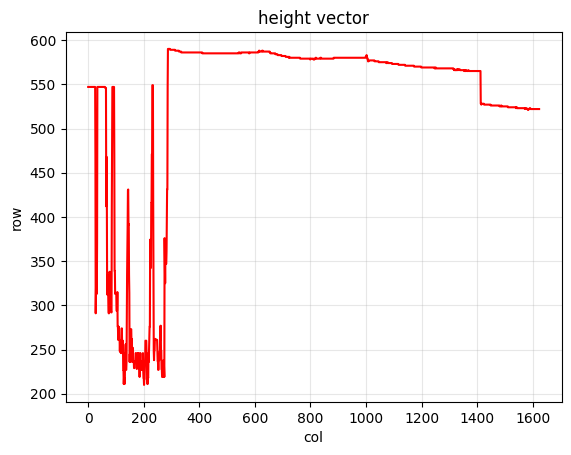

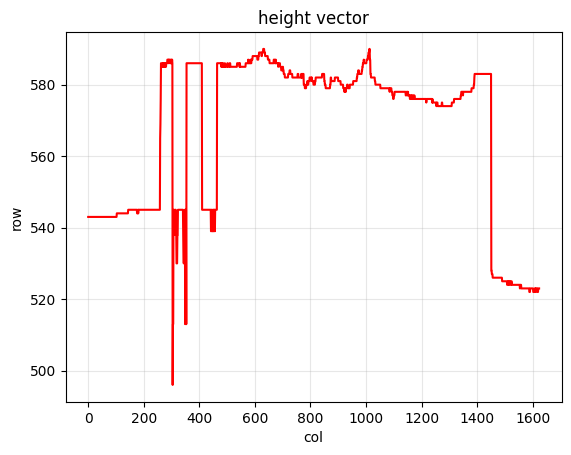

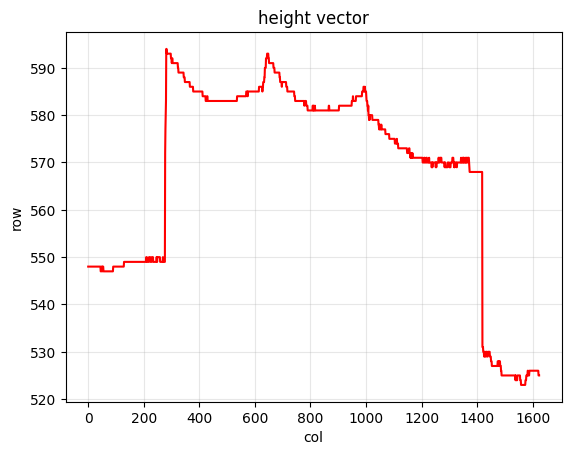

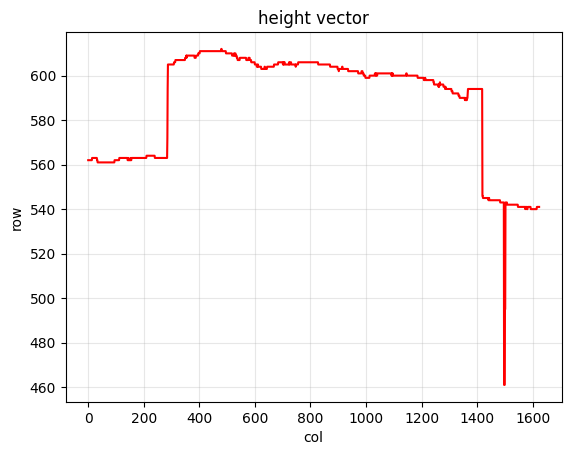

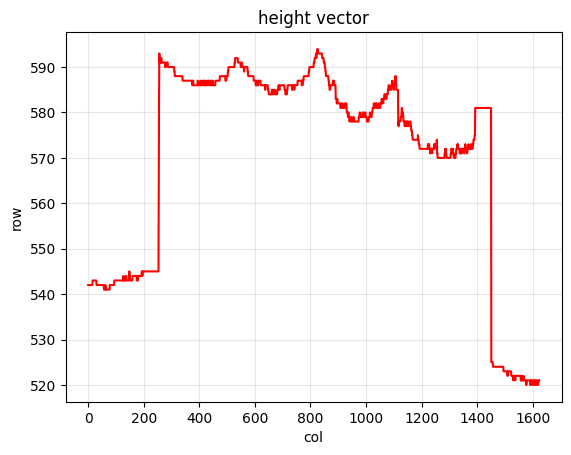

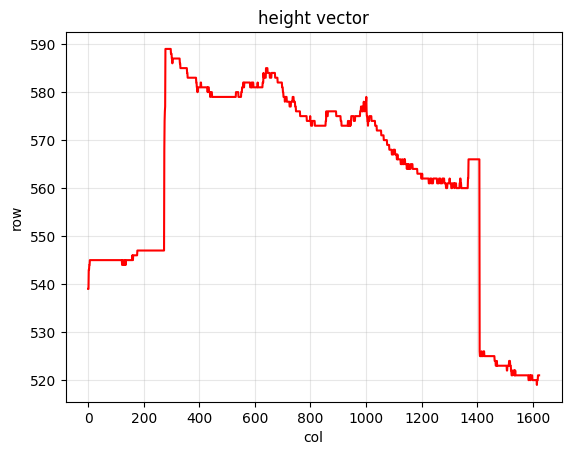

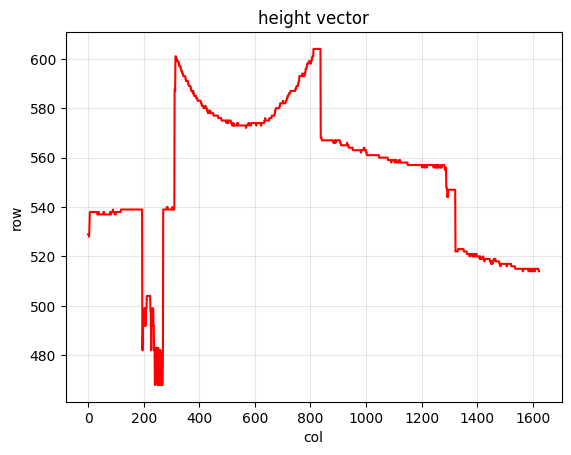

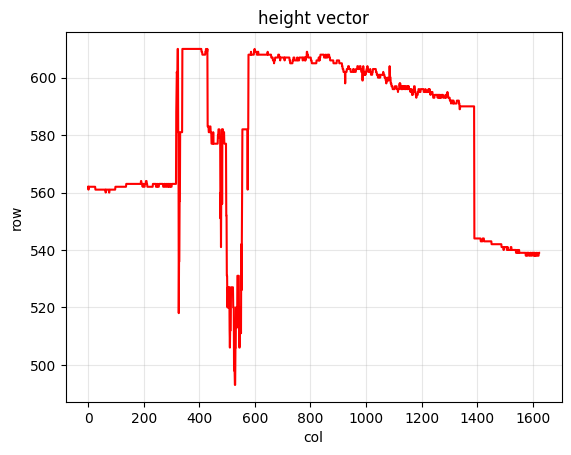

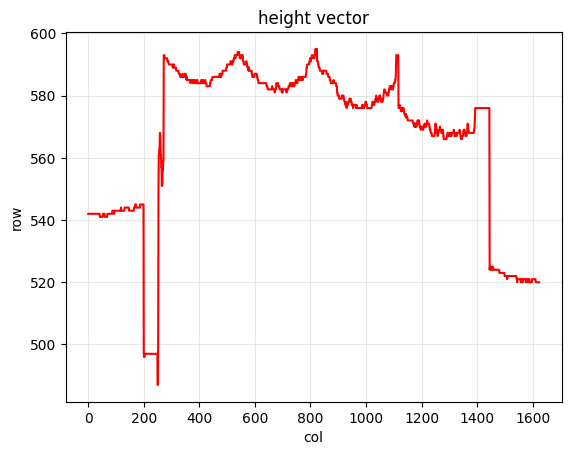

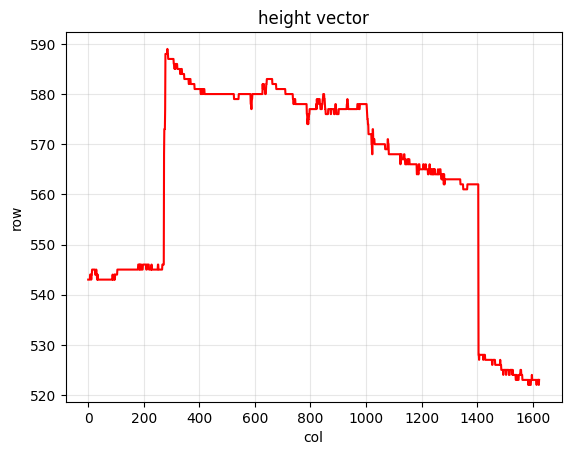

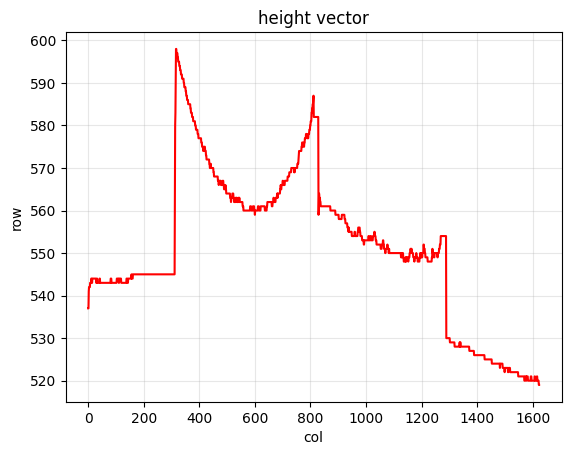

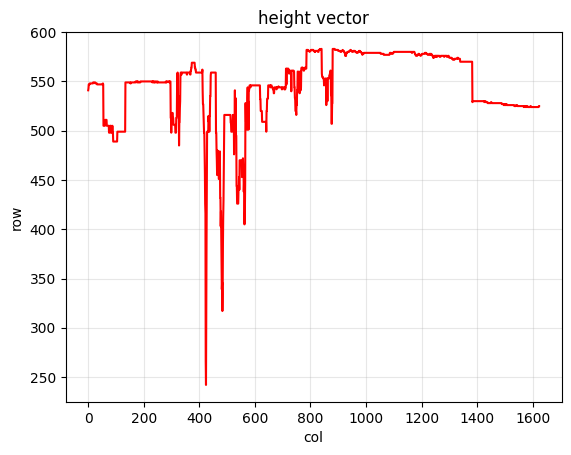

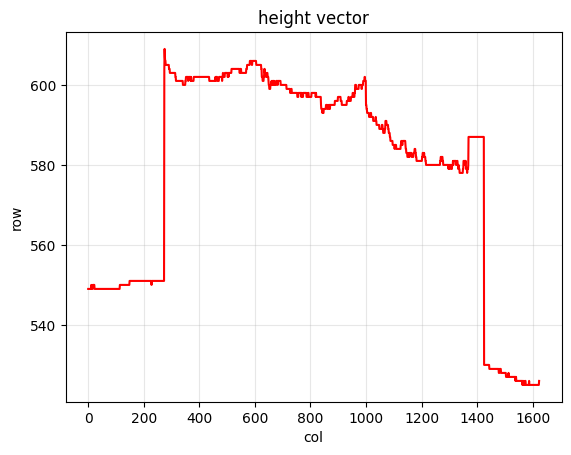

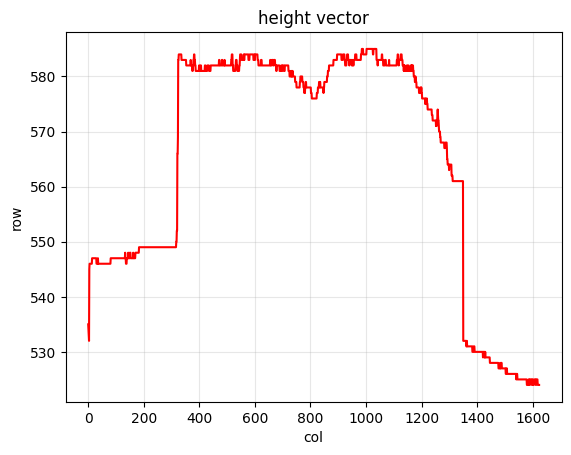

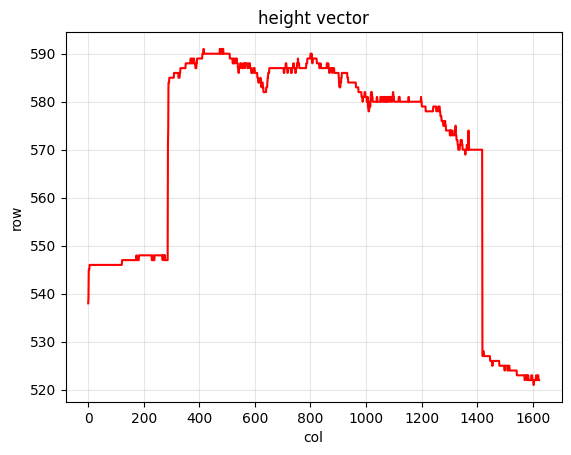

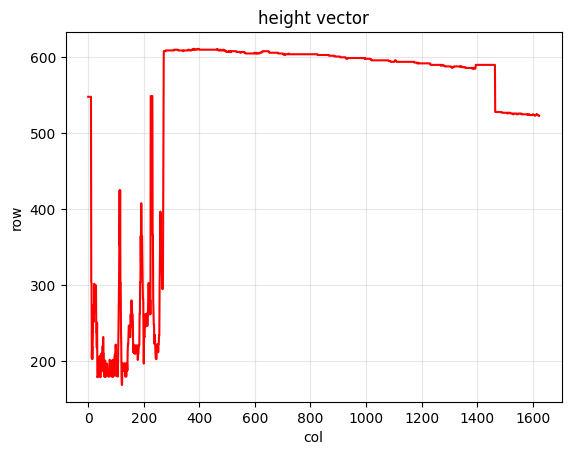

In [3]:
for dirname, _, filenames in os.walk('/kaggle/input/datasets/patrickhuang00017/warpsamples/warp_samples'):
    for filename in filenames:
        idx = filename.split(".")[0].split("_")[1]
        image_path = os.path.join(dirname, filename)
        try:
            results = extractRedLine2HeightVector(image_path, save_path=f"/kaggle/working/{idx}.png")
        except:
            print("error.")